# Stanford CME 241 (Winter 2026) - Assignment 3

**Due: Friday, February 27 @ 11:59 PM PST on Gradescope.**

Assignment instructions:
- Make sure each of the subquestions have answers
- Ensure that group members indicate which problems they're in charge of
- Show work and walk through your thought process where applicable
- Empty code blocks are for your use, so feel free to create more under each section as needed
- Document code with light comments (i.e. 'this function handles visualization')

Submission instructions:
- When complete, fill out your publicly available GitHub repo file URL and group members below, then export or print this .ipynb file to PDF and upload the PDF to Gradescope.

*Link to this ipynb file in your public GitHub repo (replace below URL with yours):* 

https://github.com/EthanSei/RL-book/blob/master/Assignments/assignment3.ipynb

*Group members (replace below names with people in your group):* 
- Ethan Seide

## Imports

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize_scalar
from typing import Iterable, Iterator, Mapping, TypeVar, Callable, Sequence, Tuple, Dict
from rl.distribution import Categorical
from rl.markov_process import FiniteMarkovRewardProcess
from rl.chapter10.prediction_utils import compare_td_and_mc
X = TypeVar('X')
S = TypeVar('S')

## Question 1: Milk Vendor Optimization Problem (Led by Ethan Seide)

You are a milk vendor and your task is to bring to your store a supply (denoted $S \in \mathbb{R}$) of milk volume in the morning that will give you the best profits. You know that the demand for milk throughout the course of the day is a probability distribution function $f$ (for mathematical convenience, assume people can buy milk in volumes that are real numbers, hence milk demand $x \in \mathbb{R}$ is a continuous variable with a probability density function). 

For every extra gallon of milk you carry at the end of the day (supply $S$ exceeds random demand $x$), you incur a cost of $h$ (effectively the wasteful purchases amounting to the difference between your purchase price and the end-of-day discount disposal price since you are not allowed to sell the same milk the next day). For every gallon of milk that a customer demands that you don't carry (random demand $x$ exceeds supply $S$), you incur a cost of $p$ (effectively the missed sales revenue amounting to the difference between your sales price and purchase price). 

Your task is to identify the optimal supply $S$ that minimizes your **Expected Cost** $g(S)$, given by:

$$
g_1(S) = \mathbb{E}[\max(x - S, 0)] = \int_{S}^{\infty} (x - S) \cdot f(x) \, dx
$$

$$
g_2(S) = \mathbb{E}[\max(S - x, 0)] = \int_{-\infty}^{S} (S - x) \cdot f(x) \, dx
$$

$$
g(S) = p \cdot g_1(S) + h \cdot g_2(S)
$$

---

### Part (A): Analytical Optimization

1. **Derive the first-order condition (FOC)** for minimizing the expected cost $g(S)$.
2. **Solve the FOC** to express the optimal supply $S^*$ in terms of the given parameters: $p$, $h$, and the demand distribution $f(x)$. (*Hint*: Pay attention to the balance between the costs of overstocking and understocking)

3. **Interpretation**: Provide an interpretation of the condition you derived. What does the balance between $p$ and $h$ imply about the optimal supply $S^*$?

---

### Part (B): Special Case Analysis

1. Consider the case where the demand $x$ follows an **exponential distribution** with parameter $\lambda > 0$. That is, $f(x) = \lambda e^{-\lambda x}$ for $x \geq 0$.
    - Derive an explicit expression for the optimal supply $S^*$.
    
2. Consider the case where the demand $x$ follows a **normal distribution** with mean $\mu$ and variance $\sigma^2$, i.e., $x \sim \mathcal{N}(\mu, \sigma^2)$. 
    - Set up the integral for $g(S)$ and describe how it relates to the **cumulative distribution function (CDF)** of the normal distribution.
    - Provide an interpretation of how changes in $\mu$ and $\sigma$ influence the optimal $S^*$. 

---

### Part (C): Framing as a Financial Options Problem

1. Frame the milk vendor's problem as a **portfolio of call and put options**:
    - Identify the analog of the "strike price" and "underlying asset."
    - Explain which part of the cost function $g_1(S)$ or $g_2(S)$ corresponds to a call option and which part to a put option.
    - What do $p$ and $h$ represent in this options framework?

2. Explain how this framing could be used to derive the optimal supply $S^*$ if solved using financial engineering concepts.

---

### Part (D): Numerical Solution and Simulation

1. **Numerical Solution**: Write a Python function that numerically estimates the optimal $S^*$ using an iterative search or numerical optimization method. 

2. **Simulation**: Generate random samples of milk demand from an exponential distribution and simulate the total costs for different values of $S$. Plot the costs against $S$ and visually identify the optimal $S$.

### Part (A) Answer

**1. FOC Derivation**

Differentiate $g(S) = p\,g_1(S) + h\,g_2(S)$ using the Leibniz rule: $\frac{d}{dS}\int_{a(S)}^{b(S)} g(x,S)\,dx = g(b,S)\,b' - g(a,S)\,a' + \int_{a}^{b} \frac{\partial g}{\partial S}\,dx$.

For $g_1(S) = \int_S^\infty (x-S)f(x)\,dx$: the lower limit is $S$ ($a'=1$), upper is $\infty$ ($b'=0$), and the integrand at $x=S$ is $(S-S)f(S)=0$, so the boundary term vanishes:

$$p\,g_1'(S) = p\int_S^\infty \frac{\partial}{\partial S}[(x-S)f(x)]\,dx = p\int_S^\infty (-1)\,f(x)\,dx = -p(1 - F(S))$$

For $g_2(S) = \int_{-\infty}^S (S-x)f(x)\,dx$: the upper limit is $S$ ($b'=1$), lower is $-\infty$ ($a'=0$), and the integrand at $x=S$ is again $(S-S)f(S)=0$:

$$h\,g_2'(S) = h\int_{-\infty}^S \frac{\partial}{\partial S}[(S-x)f(x)]\,dx = h\int_{-\infty}^S f(x)\,dx = h\,F(S)$$

Therefore:

$$g'(S) = -p(1 - F(S)) + h\,F(S) = -p + (p+h)\,F(S)$$

Setting $g'(S)=0$:

$$\boxed{F(S^*) = \frac{p}{p+h}}$$

Second-order check: $g''(S) = (p+h)f(S) > 0$ confirms a minimum.

**2. Solution**

$$\boxed{S^* = F^{-1}\!\left(\frac{p}{p+h}\right)}$$

**3. Interpretation**

The optimal supply is the demand quantile at the **critical fractile** $\frac{p}{p+h}$. If understocking is costlier ($p \gg h$), the ratio approaches 1 and we stock generously. If overstocking is costlier ($h \gg p$), the ratio approaches 0 and we stock conservatively. When $p = h$, we stock at the median.

### Part (B) Answer

#### B1: Exponential Distribution

For $f(x) = \lambda e^{-\lambda x}$, $F(x) = 1 - e^{-\lambda x}$. Applying $F(S^*) = \frac{p}{p+h}$:

$$1 - e^{-\lambda S^*} = \frac{p}{p+h} \implies e^{-\lambda S^*} = \frac{h}{p+h} \implies \boxed{S^* = \frac{1}{\lambda}\ln\!\left(\frac{p+h}{h}\right)}$$

#### B2: Normal Distribution

For $x \sim \mathcal{N}(\mu, \sigma^2)$, $F(x) = \Phi\!\left(\frac{x-\mu}{\sigma}\right)$. Substituting $d = \frac{S-\mu}{\sigma}$ and using $\int_a^\infty z\,\phi(z)\,dz = \phi(a)$, the cost components become:

$$g_1(S) = (\mu - S)(1 - \Phi(d)) + \sigma\,\phi(d), \qquad g_2(S) = (S-\mu)\,\Phi(d) + \sigma\,\phi(d)$$

Both are expressed through the standard normal CDF $\Phi$ and PDF $\phi$. From the FOC:

$$\boxed{S^* = \mu + \sigma\,\Phi^{-1}\!\left(\frac{p}{p+h}\right)}$$

**Influence of $\mu$ and $\sigma$:** Increasing $\mu$ shifts $S^*$ up directly. The effect of $\sigma$ depends on the cost asymmetry: if $p > h$, then $\Phi^{-1}(p/(p+h)) > 0$, so larger $\sigma$ increases $S^*$ (more buffer above the mean). If $p < h$, larger $\sigma$ decreases $S^*$. If $p = h$, then $S^* = \mu$ regardless of $\sigma$.

### Part (C) Answer

#### C1: Options Framing

| | Options Analog | Milk Vendor |
|---|---|---|
| **Underlying** | Asset price at expiry | Random demand $x$ |
| **Strike** | Exercise price $K$ | Supply $S$ |
| **Call** | $\mathbb{E}[\max(x-K,0)]$ | $g_1(S)$ — understocking cost |
| **Put** | $\mathbb{E}[\max(K-x,0)]$ | $g_2(S)$ — overstocking cost |

The total cost is $g(S) = p \cdot \text{Call}(S) + h \cdot \text{Put}(S)$, where $p$ and $h$ are the position sizes (cost multipliers) on the call and put respectively.

#### C2: Deriving $S^*$ via Financial Engineering

**Put-call parity:** Since $\max(x-S,0) - \max(S-x,0) = x-S$, we have $C(S) - P(S) = \mathbb{E}[x] - S$.

**Strike sensitivities:** The derivatives of option prices with respect to the strike are $\frac{\partial C}{\partial S} = -(1-F(S))$ and $\frac{\partial P}{\partial S} = F(S)$. Setting $\frac{\partial g}{\partial S} = 0$:

$$-p(1-F(S)) + h\,F(S) = 0 \implies F(S^*) = \frac{p}{p+h}$$

This recovers the same critical fractile — the vendor chooses the "strike" that balances the marginal sensitivities of the call and put positions.

### Part (D) Answer

In [8]:
# Simulation parameters
p = 5  # Cost of understocking (per unit)
h = 2  # Cost of overstocking (per unit)
lambda_param = 1.0  # Parameter for exponential distribution

# PDF and CDF for exponential demand
def demand_pdf(x):
    return lambda_param * np.exp(-lambda_param * x)

def demand_cdf(x):
    return 1 - np.exp(-lambda_param * x)

# Expected cost g(S) using closed-form expressions for Exp(lambda)
# g1(S) = (1/lambda) * exp(-lambda*S) Note: used integration by parts
# g2(S) = S - (1/lambda)(1 - exp(-lambda*S)) Note: used integration by parts
def expected_cost(S):
    inv_lam = 1.0 / lambda_param
    exp_term = np.exp(-lambda_param * S)

    g1 = inv_lam * exp_term
    g2 = S - inv_lam * (1 - exp_term)

    return p * g1 + h * g2

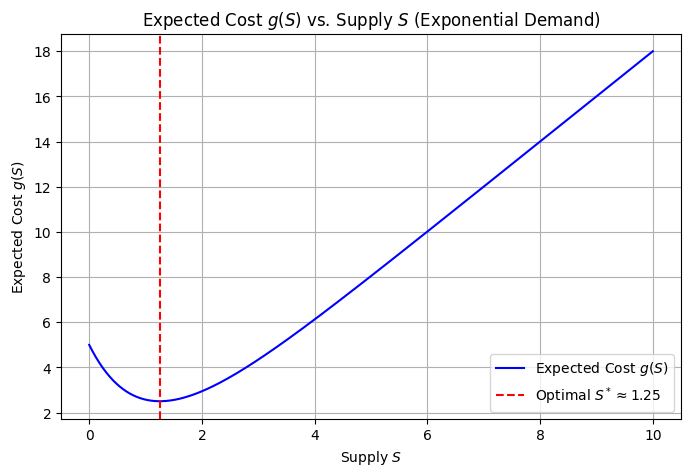

np.float64(1.252763051167479)

In [9]:
result = minimize_scalar(expected_cost, bounds=(0, 10), method='bounded')
optimal_S = result.x

# Simulation of costs
S_values = np.linspace(0, 10, 500)
costs = [expected_cost(S) for S in S_values]

# Plotting the costs against S
plt.figure(figsize=(8, 5))
plt.plot(S_values, costs, label="Expected Cost $g(S)$", color='blue')
plt.axvline(optimal_S, color='red', linestyle='--', label=f"Optimal $S^* \\approx {optimal_S:.2f}$")
plt.xlabel("Supply $S$")
plt.ylabel("Expected Cost $g(S)$")
plt.title("Expected Cost $g(S)$ vs. Supply $S$ (Exponential Demand)")
plt.legend()
plt.grid(True)
plt.show()

optimal_S

## Question 2: Car Sales (Led By: Ethan Seide)

You must sell your car within a finite window of $N$ days. At the beginning of each day $t \in \{1, \dots, N\}$, you receive a single offer $X_t$ from a dealership, where $\{X_t\}$ are i.i.d. draws from a known continuous distribution $Q$ supported on $[m, M]$, with $0 < m < M$.

After observing $X_t$, you must immediately choose whether to **accept** or **reject** the offer:

- If you **accept** on day $t$, you sell the car immediately and receive payoff $X_t$. The process then terminates.
- If you **reject** on day $t < N$, you keep the car, pay a parking cost $c \ge 0$ at the end of that day, and proceed to day $t+1$.
- On day $N$, you must accept the offer (i.e., rejecting is not allowed).

Your objective is to maximize the expected **net payoff**, defined as the sale price minus the total parking costs paid before the sale.

---

### Part (A): MDP Modeling

Model this problem as a finite-horizon **Markov Decision Process (MDP)**. Clearly specify:

1. **States**
2. **Actions**
3. **Rewards**
4. **State-transition probabilities**
5. **Discount factor** (use $\gamma = 1$)

Also state whether this MDP is finite- or infinite-horizon, episodic or continuing, and whether it is time-homogeneous.

---

### Part (B): Structure of the Optimal Policy

Let $V_t$ denote the optimal value function when there are $t$ days remaining (before observing the offer).

1. Write down the Bellman recursion for $V_t$.
2. Show that the optimal policy is a **time-dependent threshold policy**: that is, there exists a reservation price $r_t$ such that it is optimal to accept an offer $x$ if and only if $x \ge r_t$.
3. Express the threshold $r_t$ in terms of $V_{t-1}$ and $c$.

(You may leave expectations with respect to $Q$ written in integral or expectation form. A closed-form solution for general $Q$ is not required.)

---

### Part (C): Special Case (No Integrals)

Now consider the special case where $c = 0$ and $Q = \text{Uniform}[m, M]$.

1. Write the recursion for $V_t$ explicitly.
2. Provide the optimal policy in as closed-form a way as possible. Your policy may depend on recursively defined coefficients, but your final expressions should contain **no integrals**.

### Part (A) Answer

**1. States:** $s = (t, x) \in \{1,\ldots,N\} \times [m,M]$, plus a terminal state $\dagger$. At decision time on day $t$, the agent has observed offer $x = X_t$.

**2. Actions:** $\mathcal{A}(t,x) = \{\text{Accept}\}$ if $t=N$ (forced accept); else $\{\text{Accept},\text{Reject}\}$.

**3. Rewards:**
- Accept at $(t,x)$: reward $= x$, transition to $\dagger$
- Reject at $(t,x)$ ($t < N$): reward $= -c$, transition to $(t+1, X_{t+1})$ with $X_{t+1}\sim Q$

**4. Transition probabilities:**
- Accept: $(t,x)\to\dagger$ with prob 1
- Reject: $(t,x)\to(t+1,x')$ with prob density $q(x')$ (density of $Q$), independent of $(t,x)$

**5. Discount factor:** $\gamma = 1$

**Type:** Finite-horizon, episodic, **time-inhomogeneous** (the action set $\mathcal{A}(t,x)$ differs at $t=N$ vs.\ $t<N$, so the dynamics depend explicitly on $t$).

### Part (B) Answer

Let $V^*(\tau, x)$ be the optimal value at state $(\tau, x)$ — $\tau$ days remaining, current offer $x$.

**1. Bellman Optimality Equation**

Base case ($\tau = 1$, must accept):
$$V^*(1,\, x) = x$$

For $\tau \geq 2$, the two actions give:
- **Accept**: reward $x$, transition to terminal (value 0)
- **Reject**: reward $-c$, transition to $(\tau-1, x')$ with $x' \sim Q$

The Bellman optimality equation is:
$$\boxed{V^*(\tau,\, x) = \max\!\left(\;x,\;\; -c + \int_m^M V^*(\tau-1,\, x')\, q(x')\, dx'\right)}$$

where $q$ is the density of $Q$. Define $V_\tau := \int_m^M V^*(\tau, x')\,q(x')\,dx'$ as the expected value before observing the offer with $\tau$ days remaining. Then:
$$V^*(\tau, x) = \max(x,\; V_{\tau-1} - c), \qquad V_\tau = \int_m^M \max(x',\; V_{\tau-1} - c)\; q(x')\, dx'$$

**2. Threshold Policy**

Accept payoff $x$ is increasing in $x$; reject value $V_{\tau-1} - c$ is constant in $x$. They cross at exactly one point:

$$\text{Accept} \iff x \geq r_\tau, \qquad \boxed{r_\tau = V_{\tau-1} - c}$$

**3. Summary**

| $\tau$ | $V_1$ | Recursion |
|---|---|---|
| $1$ | $\mathbb{E}_Q[X]$ | base case |
| $\tau \geq 2$ | $\displaystyle\int_m^M \max(x, r_\tau)\,q(x)\,dx$ | $r_\tau = V_{\tau-1} - c$ |

**Claim:** $V_\tau$ is non-decreasing in $\tau$, i.e., $V_1 \leq V_2 \leq \cdots$ (and consequently $r_\tau = V_{\tau-1} - c$ is also non-decreasing).

*Proof by induction on $\tau$.*

**Base case ($V_2 \geq V_1$):** We have $V_1 = \mathbb{E}_Q[X]$ and $V_2 = \mathbb{E}_Q[\max(X, r_2)]$ where $r_2 = V_1 - c$. Since $\max(X, r_2) \geq X$ for every realization, taking expectations gives $V_2 \geq V_1$.

**Inductive step:** Assume $V_{\tau-1} \geq V_{\tau-2}$. Then $r_\tau = V_{\tau-1} - c \geq V_{\tau-2} - c = r_{\tau-1}$. Since $\max(x, r)$ is non-decreasing in $r$, we have $\max(x, r_\tau) \geq \max(x, r_{\tau-1})$ for every $x$. Taking expectations over $Q$:
$$V_\tau = \mathbb{E}_Q[\max(X, r_\tau)] \geq \mathbb{E}_Q[\max(X, r_{\tau-1})] = V_{\tau-1}$$

This completes the induction. $\blacksquare$

### Part (C) Answer

With $c = 0$ and $Q = \text{Uniform}[m,M]$, the threshold from Part B simplifies to $r_\tau = V_{\tau-1} - 0 = V_{\tau-1}$. Intuitively: **reject the current offer only if it's below what you expect to get from the remaining days.**

**1. Recursion for $V_\tau$**

Plugging into the Bellman equation from Part B:
$$V_\tau = \int_m^M \max(x,\, V_{\tau-1})\; \frac{dx}{M-m}$$

We split the integral at the threshold $r_\tau = V_{\tau-1}$ (which lies in $(m,M)$ by induction):

$$V_\tau = \underbrace{\int_m^{V_{\tau-1}} V_{\tau-1}\; \frac{dx}{M-m}}_{\text{offers below threshold: reject, get } V_{\tau-1}} \;+\; \underbrace{\int_{V_{\tau-1}}^{M} x\; \frac{dx}{M-m}}_{\text{offers above threshold: accept}}$$

$$= \frac{V_{\tau-1}(V_{\tau-1}-m)}{M-m} + \frac{M^2 - V_{\tau-1}^2}{2(M-m)}$$

Combining over the common denominator $2(M-m)$:

$$= \frac{2V_{\tau-1}(V_{\tau-1}-m) + M^2 - V_{\tau-1}^2}{2(M-m)} = \frac{V_{\tau-1}^2 - 2mV_{\tau-1} + M^2}{2(M-m)}$$

This factors neatly as:

$$\boxed{V_1 = \frac{m+M}{2}, \qquad V_\tau = \frac{m+M}{2} + \frac{(V_{\tau-1}-m)^2}{2(M-m)}, \quad \tau \geq 2}$$

The second term $\frac{(V_{\tau-1}-m)^2}{2(M-m)} \geq 0$ shows $V_\tau \geq V_{\tau-1}$: **having more days is always weakly better**, since you can always ignore extra days and accept the same offers you would have before.

**Claim:** $V_\tau \in (m, M)$ for all $\tau \geq 1$ (justifying the integral split above).

*Proof by induction on $\tau$:*

- **Base case** ($\tau = 1$): $V_1 = \frac{m+M}{2}$, which satisfies $m < \frac{m+M}{2} < M$.

- **Inductive step**: Suppose $V_{\tau-1} \in (m, M)$.
  - *Lower bound*: Since $V_{\tau-1} > m$, we have $(V_{\tau-1} - m)^2 > 0$, so $V_\tau = \frac{m+M}{2} + \frac{(V_{\tau-1}-m)^2}{2(M-m)} > \frac{m+M}{2} > m$.
  - *Upper bound*: Since $V_{\tau-1} < M$, we have $V_{\tau-1} - m < M - m$, so $(V_{\tau-1}-m)^2 < (M-m)^2$, giving $\frac{(V_{\tau-1}-m)^2}{2(M-m)} < \frac{M-m}{2}$. Therefore $V_\tau < \frac{m+M}{2} + \frac{M-m}{2} = M$.

Hence $V_\tau \in (m,M)$ for all $\tau \geq 1$, confirming that the threshold $V_{\tau-1}$ always lies strictly inside $[m,M]$ and the integral split is valid. $\square$

**2. Optimal Policy**

With $\tau$ days remaining, after observing offer $x$:
$$\text{Accept} \iff x \geq V_{\tau-1}$$

The threshold $V_{\tau-1}$ is your **outside option** — the expected payoff if you pass on today's offer. You accept only when today's offer beats what you could expect from the future.

**Example** ($m=0$, $M=1$): 
- $V_1 = 0.5$ — with 1 day left, you must accept; expected payoff is $E[U[0,1]] = 0.5$
- $V_2 = 0.5 + \frac{(0.5)^2}{2} = 0.625$ — with 2 days, you reject offers below $0.5$, boosting expected payoff to $0.625$
- $V_3 = 0.5 + \frac{(0.625-0)^2}{2} \approx 0.695$ — threshold rises further; you become more selective

The thresholds $V_1 < V_2 < \cdots < V_{N-1} < M$ are computed once offline from the recurrence, and the agent simply compares today's offer to the precomputed cutoff for the current number of remaining days.

## Question 3: Constrained Consumption (Led By: Ethan Seide)

Consider the following discrete-time MDP for constrained consumption. At $t = 0$, the agent is given a finite amount $x_0 \in \mathbb{R}^+$ of a resource. In each time period, the agent can choose to consume any amount of the resource, with the consumption denoted as $c \in [0, x]$ where $x$ is the amount of the resource remaining at the start of the time period. This consumption results in a reduction of the resource at the start of the next time period:  
$$x' = x - c.$$  

Consuming a quantity $c$ of the resource provides a utility of consumption equal to $U(c)$, and we adopt the **CRRA utility function**:  
$$
U(c) = \frac{c^{1 - \gamma}}{1 - \gamma}, \quad (\gamma > 0, \gamma \neq 1)
$$

Our goal is to maximize the aggregate discounted utility of consumption until the resource is completely consumed. We assume a discount factor of $\beta \in (0, 1)$ when discounting the utility of consumption over any single time period. Assume parameters are such that the value function is finite.

We model this as a **discrete-time, continuous-state-space, continuous-action-space, stationary, deterministic MDP**, and so our goal is to solve for the **Optimal Value Function** and associated **Optimal Policy**, which will give us the optimal consumption trajectory of the resource. Since this is a stationary MDP, the **State** is simply the amount $x$ of the resource remaining at the start of a time period. The **Action** is the consumption quantity $c$ in that time period. The **Reward** for a time period is $U(c)$ when the consumption in that time period is $c$. The discount factor over each single time period is $\beta$.

We assume that the **Optimal Policy** is given by:  
$$
c^* = \theta^* \cdot x \quad \text{for some } \theta^* \in [0, 1].
$$

---

### Part (A): Closed-form Expression for $V_\theta(x)$

Our first step is to consider a fixed deterministic policy, given by:  
$$c = \theta \cdot x \quad \text{for some fixed } \theta \in [0, 1].$$  
Derive a closed-form expression for the **Value Function** $V_\theta(x)$ for a fixed deterministic policy, given by $c = \theta \cdot x$. Specifically, you need to express $V_\theta(x)$ in terms of $\beta$, $\gamma$, $\theta$, and $x$.

---

### Part (B): Solving for $\theta^*$

Use this closed-form expression for $V_\theta(x)$ to solve for the $\theta^*$ which maximizes $V_\theta(x)$ (thus fetching us the **Optimal Policy** given by $c^* = \theta^* \cdot x$).

---

### Part (C): Expression for $V^*(x)$

Use this expression for $\theta^*$ to obtain an expression for the **Optimal Value Function** $V^*(x)$ in terms of only $\beta$, $\gamma$, and $x$.

---

### Part (D): Validation of the Bellman Equation

Validate that the **Optimal Policy** (derived in part B) and **Optimal Value Function** (derived in part C) satisfy the **Bellman Optimality Equation**.

### Part (A) Answer

Under the fixed policy $c = \theta x$, the resource evolves as $x_t = (1-\theta)^t x_0$, and consumption at time $t$ is $c_t = \theta(1-\theta)^t x_0$. The value function is:

$$V_\theta(x) = \sum_{t=0}^{\infty} \beta^t \, U\!\left(\theta(1-\theta)^t x\right) = \sum_{t=0}^{\infty} \beta^t \frac{\left(\theta(1-\theta)^t x\right)^{1-\gamma}}{1-\gamma}$$

Factor out the constants:

$$= \frac{(\theta x)^{1-\gamma}}{1-\gamma} \sum_{t=0}^{\infty} \left[\beta(1-\theta)^{1-\gamma}\right]^t$$

This is a geometric series converging when $\beta(1-\theta)^{1-\gamma} < 1$, giving:

$$\boxed{V_\theta(x) = \frac{\theta^{1-\gamma}}{1 - \beta(1-\theta)^{1-\gamma}} \cdot \frac{x^{1-\gamma}}{1-\gamma}}$$

**Verification via Bellman equation for fixed policy:** We can confirm by checking $V_\theta(x) = U(\theta x) + \beta V_\theta((1-\theta)x)$:

$$\text{RHS} = \frac{(\theta x)^{1-\gamma}}{1-\gamma} + \beta \cdot \frac{\theta^{1-\gamma}((1-\theta)x)^{1-\gamma}}{(1-\gamma)(1-\beta(1-\theta)^{1-\gamma})} = \frac{(\theta x)^{1-\gamma}}{1-\gamma}\left[1 + \frac{\beta(1-\theta)^{1-\gamma}}{1-\beta(1-\theta)^{1-\gamma}}\right] = \frac{(\theta x)^{1-\gamma}}{(1-\gamma)(1-\beta(1-\theta)^{1-\gamma})} = V_\theta(x) \;\checkmark$$

### Part (B) Answer

Write $V_\theta(x) = K(\theta) \cdot \frac{x^{1-\gamma}}{1-\gamma}$ where $K(\theta) = \frac{\theta^{1-\gamma}}{1 - \beta(1-\theta)^{1-\gamma}}$. Maximizing $V_\theta$ over $\theta$ is equivalent to finding the critical point of $K(\theta)$ (the sign of $\frac{x^{1-\gamma}}{1-\gamma}$ is constant in $\theta$, so the extremum location is the same).

**FOC.** Setting $K'(\theta) = 0$ using the quotient rule with $D(\theta) = 1 - \beta(1-\theta)^{1-\gamma}$:

$$K'(\theta) = \frac{(1-\gamma)\theta^{-\gamma}\,D(\theta) - \theta^{1-\gamma}\,D'(\theta)}{D(\theta)^2} = 0$$

Since $D'(\theta) = \beta(1-\gamma)(1-\theta)^{-\gamma}$, the numerator condition becomes:

$$(1-\gamma)\theta^{-\gamma}\left[1 - \beta(1-\theta)^{1-\gamma}\right] = \theta^{1-\gamma} \cdot \beta(1-\gamma)(1-\theta)^{-\gamma}$$

Divide by $(1-\gamma)\theta^{-\gamma}$ (both nonzero):

$$1 - \beta(1-\theta)^{1-\gamma} = \beta\,\theta\,(1-\theta)^{-\gamma}$$

Expand the left side and collect $\beta$ terms:

$$1 = \beta\!\left[(1-\theta)^{1-\gamma} + \theta(1-\theta)^{-\gamma}\right] = \beta(1-\theta)^{-\gamma}\!\left[(1-\theta) + \theta\right] = \beta(1-\theta)^{-\gamma}$$

Therefore $(1-\theta)^{\gamma} = \beta$, giving:

$$\boxed{\theta^* = 1 - \beta^{1/\gamma}}$$

Since $0 < \beta < 1$ and $\gamma > 0$, we have $\beta^{1/\gamma} \in (0,1)$, so $\theta^* \in (0,1)$. The optimal policy is $c^* = (1 - \beta^{1/\gamma})\,x$.

**Intuition:** Higher $\beta$ (more patience) $\Rightarrow$ smaller $\theta^*$ (consume less now). Higher $\gamma$ (more risk aversion / desire to smooth) $\Rightarrow \beta^{1/\gamma}$ closer to 1 $\Rightarrow$ smaller $\theta^*$ (spread consumption more evenly).

### Part (C) Answer

Substitute $\theta^* = 1 - \beta^{1/\gamma}$ into $V^*(x) = K^* \cdot \frac{x^{1-\gamma}}{1-\gamma}$ where $K^* = \frac{(\theta^*)^{1-\gamma}}{1 - \beta(1-\theta^*)^{1-\gamma}}$.

**Simplify the denominator.** Since $1-\theta^* = \beta^{1/\gamma}$:

$$\beta(1-\theta^*)^{1-\gamma} = \beta \cdot \beta^{(1-\gamma)/\gamma} = \beta^{1 + (1-\gamma)/\gamma} = \beta^{1/\gamma}$$

So $1 - \beta(1-\theta^*)^{1-\gamma} = 1 - \beta^{1/\gamma} = \theta^*$.

**Therefore:**

$$K^* = \frac{(\theta^*)^{1-\gamma}}{\theta^*} = (\theta^*)^{-\gamma}$$

$$\boxed{V^*(x) = \frac{(1 - \beta^{1/\gamma})^{-\gamma}}{1-\gamma}\; x^{1-\gamma}}$$

### Part (D) Answer

We verify the **Bellman Optimality Equation**: $V^*(x) = \max_{c \in [0,x]}\left[U(c) + \beta\, V^*(x-c)\right]$.

**Step 1: Check that $c^* = \theta^* x$ satisfies the FOC.**

$$\frac{\partial}{\partial c}\left[\frac{c^{1-\gamma}}{1-\gamma} + \beta\,(\theta^*)^{-\gamma}\,\frac{(x-c)^{1-\gamma}}{1-\gamma}\right] = c^{-\gamma} - \beta\,(\theta^*)^{-\gamma}(x-c)^{-\gamma} = 0$$

At $c = \theta^* x$, $x - c = (1-\theta^*)x = \beta^{1/\gamma}x$:
- LHS: $(\theta^* x)^{-\gamma} = (\theta^*)^{-\gamma}x^{-\gamma}$
- RHS: $\beta(\theta^*)^{-\gamma}(\beta^{1/\gamma}x)^{-\gamma} = \beta \cdot \beta^{-1} \cdot (\theta^*)^{-\gamma}x^{-\gamma} = (\theta^*)^{-\gamma}x^{-\gamma}$

LHS $=$ RHS $\;\checkmark$

**SOC:** $\frac{\partial^2}{\partial c^2}[\cdots] = -\gamma\,c^{-\gamma-1} - \beta(\theta^*)^{-\gamma}\gamma(x-c)^{-\gamma-1} < 0 \;\checkmark$ (confirms maximum)

**Step 2: Verify $U(c^*) + \beta V^*(x - c^*) = V^*(x)$.**

$$U(c^*) = \frac{(\theta^* x)^{1-\gamma}}{1-\gamma} = (\theta^*)^{1-\gamma}\cdot\frac{x^{1-\gamma}}{1-\gamma}$$

$$\beta\,V^*(\beta^{1/\gamma}x) = \beta\,(\theta^*)^{-\gamma}\,\frac{(\beta^{1/\gamma}x)^{1-\gamma}}{1-\gamma} = \beta^{1/\gamma}\,(\theta^*)^{-\gamma}\,\frac{x^{1-\gamma}}{1-\gamma}$$

(using $\beta \cdot \beta^{(1-\gamma)/\gamma} = \beta^{1/\gamma}$). Adding:

$$U(c^*) + \beta V^*(x-c^*) = (\theta^*)^{-\gamma}\,\frac{x^{1-\gamma}}{1-\gamma}\underbrace{\left[\theta^* + \beta^{1/\gamma}\right]}_{= \theta^* + (1-\theta^*) = 1} = (\theta^*)^{-\gamma}\,\frac{x^{1-\gamma}}{1-\gamma} = V^*(x) \quad\blacksquare$$

## Problem 4: Double Q-Learning (Led By: Ethan Seide)

It is known that **Q-Learning** can suffer from maximization bias during finite-sample training. In this problem, we consider a modification of tabular Q-Learning called **Double Q-Learning**, which reduces this bias by decoupling action selection and evaluation.

---

### **Algorithm 1: Double Q-Learning**

**Initialize** $Q_1(s,a)$ and $Q_2(s,a)$ for all $s \in \mathcal{S}$, $a \in \mathcal{A}$  
**yield** estimate of $Q$

**while** True **do**  
&emsp; **select** initial state $s_0$, set $t = 0$  
&emsp; **while** $s_t$ is non-terminal **do**  

&emsp;&emsp; **select** $a_t$ using $\epsilon$-greedy with respect to  
&emsp;&emsp; $\displaystyle \pi(s) = \arg\max_a \big( Q_1(s,a) + Q_2(s,a) \big)$  

&emsp;&emsp; **observe** $(r_t, s_{t+1})$  

&emsp;&emsp; **with probability 0.5 update $Q_1$:**

&emsp;&emsp;&emsp; Let  
&emsp;&emsp;&emsp; $\displaystyle a^* = \arg\max_a Q_1(s_{t+1}, a)$  

&emsp;&emsp;&emsp; Update  
&emsp;&emsp;&emsp; $\displaystyle Q_1(s_t, a_t) \leftarrow Q_1(s_t, a_t) + \alpha \Big( r_t + \gamma Q_2(s_{t+1}, a^*) - Q_1(s_t, a_t) \Big)$

&emsp;&emsp; **otherwise update $Q_2$:**

&emsp;&emsp;&emsp; Let  
&emsp;&emsp;&emsp; $\displaystyle a^* = \arg\max_a Q_2(s_{t+1}, a)$  

&emsp;&emsp;&emsp; Update  
&emsp;&emsp;&emsp; $\displaystyle Q_2(s_t, a_t) \leftarrow Q_2(s_t, a_t) + \alpha \Big( r_t + \gamma Q_1(s_{t+1}, a^*) - Q_2(s_t, a_t) \Big)$

&emsp;&emsp; $t \leftarrow t + 1$  
&emsp;&emsp; $s_t \leftarrow s_{t+1}$  

**yield** estimate $Q_1 + Q_2$

---

### **Algorithm 2: Q-Learning**

**Initialize** $Q(s,a)$ for all $s \in \mathcal{S}$, $a \in \mathcal{A}$  
**yield** $Q$

**while** True **do**  
&emsp; **select** initial state $s_0$, set $t = 0$  
&emsp; **while** $s_t$ is non-terminal **do**  

&emsp;&emsp; **select** $a_t$ using $\epsilon$-greedy with respect to  
&emsp;&emsp; $\displaystyle \pi(s) = \arg\max_a Q(s,a)$  

&emsp;&emsp; **observe** $(r_t, s_{t+1})$  

&emsp;&emsp; Update  
&emsp;&emsp; $\displaystyle Q(s_t, a_t) \leftarrow Q(s_t, a_t) + \alpha \Big( r_t + \gamma \max_a Q(s_{t+1}, a) - Q(s_t, a_t) \Big)$

&emsp;&emsp; $t \leftarrow t + 1$  
&emsp;&emsp; $s_t \leftarrow s_{t+1}$  

**yield** $Q$

---

### Instructions

The code skeleton for this problem is provided below. Implement the functions:

- `double_q_learning`
- `q_learning`

After running both algorithms, you will obtain a plot of the estimated Q-value versus episode number.

In your writeup:

1. Compare the behavior of Q-Learning and Double Q-Learning.
2. Explain why Q-Learning can exhibit maximization bias.
3. Discuss the advantages and possible drawbacks of Double Q-Learning in general MDPs.

In [10]:
import random
import numpy as np
import matplotlib.pyplot as plt

from dataclasses import dataclass
from collections import defaultdict
from typing import Mapping, Iterator, TypeVar, Tuple, Dict, Iterable, Generic

# RL imports (adapt or remove if you don't have the same environment):
from rl.distribution import (
    Distribution, Constant, Gaussian, Choose, SampledDistribution, Categorical
)
from rl.markov_process import NonTerminal, State, Terminal
from rl.markov_decision_process import MarkovDecisionProcess
from rl.td import epsilon_greedy_action

S = TypeVar('S')
A = TypeVar('A')

In [12]:
# -----------------------------------------------------------------------
# Tabular Q-value function approximation (done for you)
# -----------------------------------------------------------------------
class TabularQValueFunctionApprox(Generic[S, A]):
    """
    A basic implementation of a tabular function approximation 
    with constant learning rate of 0.1
    Also tracks the number of updates per (state, action).
    """
    def __init__(self):
        self.counts: Mapping[Tuple[NonTerminal[S], A], int] = defaultdict(int)
        self.values: Mapping[Tuple[NonTerminal[S], A], float] = defaultdict(float)
    
    def update(self, k: Tuple[NonTerminal[S], A], target: float) -> None:
        alpha = 0.1
        old_val = self.values[k]
        self.values[k] = (1 - alpha) * old_val + alpha * target
        self.counts[k] += 1
    
    def __call__(self, x: Tuple[NonTerminal[S], A]) -> float:
        return self.values[x]

In [18]:
# -----------------------------------------------------------------------
# Double Q-Learning (fill in)
# -----------------------------------------------------------------------
def double_q_learning(
    mdp: MarkovDecisionProcess[S, A],
    states: Distribution[NonTerminal[S]],
    gamma: float
) -> Iterator[TabularQValueFunctionApprox[S, A]]:
    """
    Implements Double Q-Learning as described:
      1) We keep two Q-tables, Q1 and Q2.
      2) We choose actions epsilon-greedily with respect to Q1+Q2.
      3) With 50% chance we update Q1 using next-action chosen by max of Q2,
         otherwise update Q2 using next-action chosen by max of Q1.
    """
    Q1 = TabularQValueFunctionApprox()
    Q2 = TabularQValueFunctionApprox()
    eps = 0.1
    yield lambda sa: Q1(sa) + Q2(sa)

    while True:
        state = states.sample()
        t = 0

        while isinstance(state, NonTerminal):
            action = epsilon_greedy_action(lambda sa: Q1(sa) + Q2(sa), state, mdp.actions(state), eps)

            (new_state, reward) = mdp.step(state, action).sample()
            if random.random() < 0.5:
                if isinstance(new_state, NonTerminal):
                    new_actions = mdp.actions(new_state)
                    a_star = new_actions[np.argmax([Q1((new_state, a)) for a in new_actions])]
                    target = reward + gamma * Q2((new_state, a_star)) if isinstance(new_state, NonTerminal) else reward
                else:
                    target = reward
                Q1.update((state, action), target)
            else:
                if isinstance(new_state, NonTerminal):
                    new_actions = mdp.actions(new_state)
                    a_star = new_actions[np.argmax([Q2((new_state, a)) for a in new_actions])]
                    target = reward + gamma * Q1((new_state, a_star)) if isinstance(new_state, NonTerminal) else reward
                else:
                    target = reward
                Q2.update((state, action), target)
            t += 1
            state = new_state
        yield lambda sa: Q1(sa) + Q2(sa)


In [19]:
# -----------------------------------------------------------------------
# Standard Q-Learning (fill in)
# -----------------------------------------------------------------------
def q_learning(
    mdp: MarkovDecisionProcess[S, A],
    states: Distribution[NonTerminal[S]],
    gamma: float
) -> Iterator[TabularQValueFunctionApprox[S, A]]:
    """
    Standard Q-Learning:
      1) Keep one Q table
      2) Epsilon-greedy wrt that table
      3) Update Q((s,a)) with  r + gamma * max_{a'} Q((s_next, a'))
    """
    Q = TabularQValueFunctionApprox()
    eps = 0.1
    yield Q

    while True:
        state = states.sample()
        t = 0
        while isinstance(state, NonTerminal):
            action = epsilon_greedy_action(Q, state, mdp.actions(state), eps)
            (new_state, reward) = mdp.step(state, action).sample()
            if isinstance(new_state, NonTerminal):
              new_actions = mdp.actions(new_state)
              target = reward + gamma * max([Q((new_state, a)) for a in new_actions])
            else:
                target = reward
            Q.update((state, action), target)

            t += 1
            state = new_state
        
        yield Q

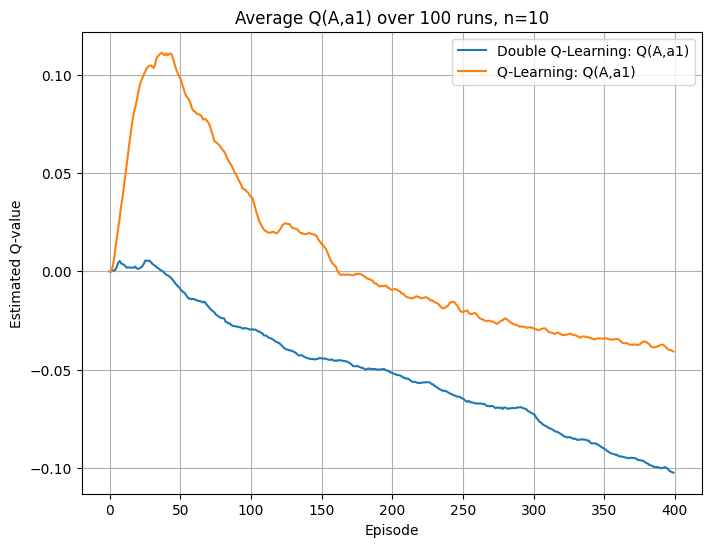

In [20]:
# -----------------------------------------------------------------------
# The MDP: States A,B and actions a1,a2,b1,...,bn (don't modify anything anymore, just run to get the graphs)
# -----------------------------------------------------------------------
@dataclass(frozen=True)
class P1State:
    """
    The MDP state, storing whether we are in "A" or "B".
    """
    name: str

class P1MDP(MarkovDecisionProcess[P1State, str]):
    
    def __init__(self, n: int):
        self.n = n

    def actions(self, state: NonTerminal[P1State]) -> Iterable[str]:
        """
        Return the actions available from this state.
          - if state is A => ["a1", "a2"]
          - if state is B => ["b1", ..., "bn"]
        """
        if state.state.name == "A":
            return ["a1", "a2"]
        else:
            return [f"b{i}" for i in range(1, self.n+1)]
    
    def step(
        self,
        state: NonTerminal[P1State],
        action: str
    ) -> Distribution[Tuple[State[P1State], float]]:
        """
        Return the distribution of (next state, reward) from (state, action):
          - A + a1 => reward 0, next state B
          - A + a2 => reward 0, next state terminal
          - B + b_i => reward ~ Normal(-0.1,1), next state terminal
        """
        if state.state.name == "A":
            if action == "a1":
                return Constant((NonTerminal(P1State("B")), 0.0))
            else:
                return Constant((Terminal(P1State("T")), 0.0))
        else:
            # For B + b_i => reward ~ N(-0.1,1), then terminal
            def sampler():
                r = np.random.normal(loc=-0.1, scale=1.0)
                return (Terminal(P1State("T")), r)
            return SampledDistribution(sampler)

def run_double_q_once(mdp, start_dist, gamma=1.0, episodes=400):
    """
    Runs one 'chain' of Double Q-Learning for 'episodes' episodes,
    returning a list of Q-values for Q((A,a1)) at the end of each episode.
    """
    dq_iter = double_q_learning(mdp, start_dist, gamma)  # generator
    vals = []
    for _ in range(episodes):
        Q1 = next(dq_iter)
        # record Q1((A,a1)) each time
        qA1 = Q1((NonTerminal(P1State("A")), "a1"))
        vals.append(qA1)
    return vals

def run_q_once(mdp, start_dist, gamma=1.0, episodes=400):
    """
    Same but for standard Q-Learning
    """
    q_iter = q_learning(mdp, start_dist, gamma)
    vals = []
    for _ in range(episodes):
        Q = next(q_iter)
        qA1 = Q((NonTerminal(P1State("A")), "a1"))
        vals.append(qA1)
    return vals

def main():
    # For reproducibility
    random.seed(0)
    np.random.seed(0)

    n = 10
    mdp = P1MDP(n)
    # Always start in A, as a NonTerminal
    start_dist = Constant(NonTerminal(P1State("A")))

    N_RUNS = 100
    N_EPISODES = 400

    all_dbl = []
    all_std = []

    for _ in range(N_RUNS):
        dbl_vals = run_double_q_once(mdp, start_dist, gamma=1.0, episodes=N_EPISODES)
        std_vals = run_q_once(mdp, start_dist, gamma=1.0, episodes=N_EPISODES)
        all_dbl.append(dbl_vals)
        all_std.append(std_vals)

    arr_dbl = np.array(all_dbl)
    arr_std = np.array(all_std)

    avg_dbl = np.mean(arr_dbl, axis=0)
    avg_std = np.mean(arr_std, axis=0)

    plt.figure(figsize=(8,6))
    plt.plot(avg_dbl, label='Double Q-Learning: Q(A,a1)')
    plt.plot(avg_std, label='Q-Learning: Q(A,a1)')
    plt.xlabel('Episode')
    plt.ylabel('Estimated Q-value')
    plt.title('Average Q(A,a1) over 100 runs, n=10')
    plt.legend()
    plt.grid(True)
    plt.show()

if __name__ == "__main__":
    main()

### Analysis

**1. Comparison:** Q-learning significantly overestimates $Q(A, a_1)$ in early episodes (peaking around $+0.1$ vs the true value of $-0.1$), while Double Q-learning stays much closer to the true value throughout. Both converge eventually, but Q-learning is much slower.

**2. Maximization bias:** Q-learning uses the same Q-table to both select the best action and evaluate it. With noisy estimates, $\max$ over noise is positively biased — $\mathbb{E}[\max_a Q(s',a)] \geq \max_a \mathbb{E}[Q(s',a)]$ by Jensen's inequality. Here, $n=10$ actions from state $B$ all have true reward $-0.1$, but early noise makes some estimates positive, and $\max$ picks those out.

**3. Double Q-Learning tradeoffs:** The key advantage is eliminating this bias by decoupling selection ($\arg\max$ on $Q_1$) from evaluation (value from $Q_2$). The main drawback is that each table only gets half the updates, increasing per-table variance. It also doubles memory and can slightly underestimate values.